In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [ ]:
# Custom loader function for .npy files
def npy_loader(path):
    """Load .npy file and convert to tensor"""
    image = np.load(path).astype(np.float32)
    
    image = torch.from_numpy(image)

    # Add channel dimension but keep as numpy
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)

    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image  # (H, W) -> (3, H, W)

synth_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/synth",
    extensions = (".npy"),
    loader = npy_loader,
)
meas_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/real",
    extensions = (".npy"),
    loader = npy_loader,
)

In [60]:
synth_ds[0][0].shape # Check the shape of the first image in the synthetic dataset

torch.Size([3, 128, 128])

In [ ]:
synth_vals = []

for i in range(len(synth_ds)):
    u, sigma = synth_ds[i][0][0].mean(), synth_ds[i][0][0].std()
    synth_vals.append((u.item(), sigma.item()))

In [ ]:
meas_vals = []

for i in range(len(meas_ds)):
    u, sigma = meas_ds[i][0][0].mean(), meas_ds[i][0][0].std()
    meas_vals.append((u.item(), sigma.item()))

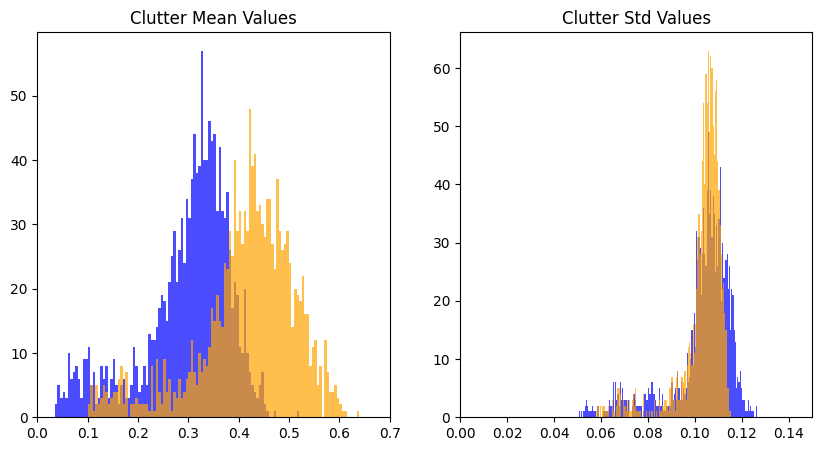

In [58]:
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in synth_vals], bins = np.arange(0, 1, 0.005), alpha=0.7, label='Synthetic', color='blue')
ax1.hist([val[0] for val in meas_vals], bins = np.arange(0, 1, 0.005), alpha=0.7, label='Measured', color='orange')
ax1.set_xlim(0, 0.7)
ax1.set_title("Clutter Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in synth_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label='Synthetic', color='blue')
ax2.hist([val[1] for val in meas_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label='Measured', color='orange')
ax2.set_xlim(0, 0.15)
ax2.set_title("Clutter Std Values")
plt.show()